In [1]:
import os
if 'PATH_SET' not in locals():
    os.chdir('../..')
    PATH_SET = True
    
import torch    

if 'THREADS_SET' not in locals():
    try:
        os.environ['OMP_NUM_THREADS'] = '1'
        os.environ['MKL_NUM_THREADS'] = '1'
        
        torch.set_num_threads(1)
        torch.set_num_interop_threads(1)
        THREADS_SET = True
    except:
        pass

import numpy as np

import xarray as xr
import shapely

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle_background.mplstyle')

figure_path = 'figures/priors/data_prior/'
os.makedirs(figure_path, exist_ok=True)

In [2]:
from helpers.geographic_setup import (
    design_space_full, design_space_shoulder,
    events_shoulder, events_full,
    topo_data
)

In [3]:
topo_spacing = 15

topo_data_interp = topo_data.interp(
    easting=np.arange(topo_data.easting.min(), topo_data.easting.max(), topo_spacing),
    northing=np.arange(topo_data.northing.min(), topo_data.northing.max(), topo_spacing)
)

x_min, x_max, x_N = (
    topo_data_interp.easting.values.min(),
    topo_data_interp.easting.values.max(),
    topo_data_interp.easting.size)

y_min, y_max, y_N = (
    topo_data_interp.northing.values.min(),
    topo_data_interp.northing.values.max(),
    topo_data_interp.northing.size)

z_min, z_max = (
    topo_data_interp.values.min()-300,
    topo_data_interp.values.max()
)
dz = 5
z_N = int((z_max - z_min) // dz) # 2 m resolution

x = np.linspace(x_min, x_max, x_N)
y = np.linspace(y_min, y_max, y_N)
z = np.linspace(z_min, z_max, z_N)

print(f'x: {x_min} - {x_max} ({x_N})')
print(f'y: {y_min} - {y_max} ({y_N})')
print(f'z: {z_min} - {z_max} ({z_N})')

x: 0.0 - 2475.0 (166)
y: 0.0 - 2475.0 (166)
z: 1204.3962499999998 - 2678.9849999999997 (294)


In [ ]:
seismic_grid = xr.DataArray(
    np.moveaxis(np.linspace(z_min, z_max, z_N).repeat(x_N * y_N).reshape(z_N, y_N, x_N), 0, -1),
    dims=('easting', 'northing', 'elevation'),
    coords={
        'easting': x,
        'northing': y,
        'elevation': z
    }
)

AIR_VELOCITY = 330.0
V_0 = 1000.0
V_G = 1000.0/100.0 # velocity increases by 1000 m/s per 100 m depth
V_MAX = 5500.0

elevations = (topo_data_interp.interp(
    easting=seismic_grid.easting,
    northing=seismic_grid.northing).values).repeat(z_N).reshape(x_N, y_N, z_N)

seismic_grid = elevations - seismic_grid

seismic_grid.values[ seismic_grid.values >  -topo_spacing] = \
    V_0 + V_G * seismic_grid.values[ seismic_grid.values >  -topo_spacing]
seismic_grid.values[ seismic_grid.values <= -topo_spacing] = \
    AIR_VELOCITY
seismic_grid.values[ seismic_grid.values > V_MAX] = V_MAX


seismic_grid.to_netcdf(
    'data/velocity_model/vel_model_gradient.nc',format='NETCDF4', engine='netcdf4')

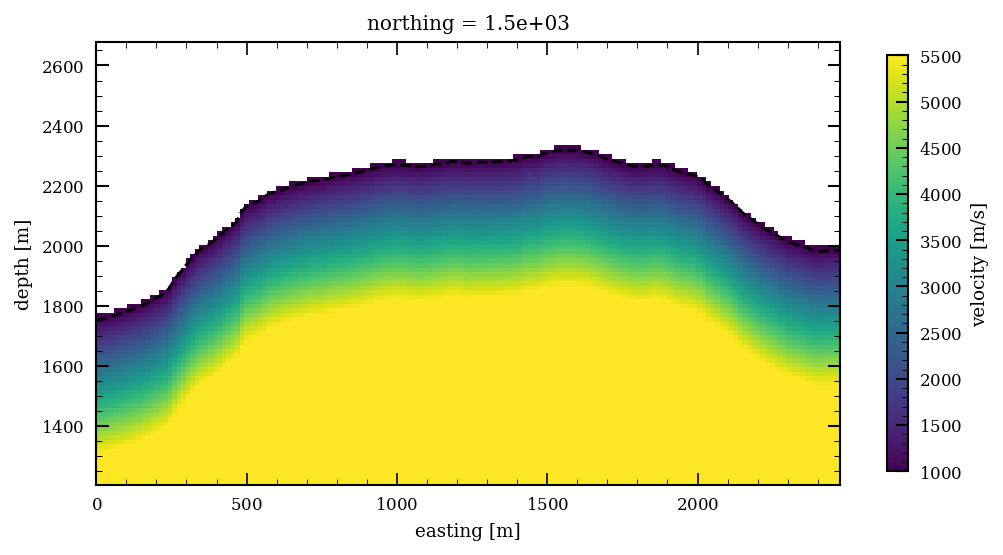

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

im_values = seismic_grid.sel(northing=1500, method='nearest').T
im_values = xr.where(im_values < 500, np.nan, im_values) 

ax.imshow(
    im_values, origin='lower',
    extent=[x_min, x_max, z_min, z_max],
    cmap='viridis', vmin=1000, vmax=5500)
ax.set_aspect('equal')

topo_data_interp.sel(northing=1500, method='nearest').plot(ax=ax, color='k', linestyle='--')

ax.set_xlabel('easting [m]')
ax.set_ylabel('depth [m]')

# # 511.54000899987295 - 1623.540008999873 (222)
# ax.set_xlim(511.54000899987295, 1623.540008999873)
# # z: 1716.465114550861 - 2363.9375812938033 (258)
# ax.set_ylim(1716.465114550861, 2363.9375812938033)

plt.colorbar(ax.images[0], ax=ax, label='velocity [m/s]', shrink=0.6)

plt.show()

In [ ]:
prior_samples_full_disp = torch.load('data/priors/prior_samples_full_disp.pt')
prior_samples_full_uniform = torch.load('data/priors/prior_samples_full_uniform.pt')
prior_samples_shoulder_uniform = torch.load('data/priors/prior_samples_shoulder_uniform.pt')


In [ ]:
design_space_full

# WARNING: Not quite the same since faulty receivers are remove from shoulder design space
# but not from full design space, we only use real data for the shoulder design space
design_space_shoulder;

In [ ]:
import pykonal

class Pykonal_Forward:
    def __init__(self, x, y, z, seismic_grid):
        self.x_min, self.x_max, self.x_N = x.min(), x.max(), x.size
        self.y_min, self.y_max, self.y_N = y.min(), y.max(), y.size
        self.z_min, self.z_max, self.z_N = z.min(), z.max(), z.size      

        self.dx = (x_max - x_min) / x_N
        self.dy = (y_max - y_min) / y_N
        self.dz = (z_max - z_min) / z_N
                
        self.seismic_grid = seismic_grid
                
    def forward(self, source_coords):
        
        # receiver_vert = get_elevation(receiver_coords[..., :2], topo_ds_interp)
        # receiver_coords = np.hstack([receiver_coords, receiver_vert[:, None]])
        
        solver = pykonal.solver.PointSourceSolver()
        solver.velocity.min_coords     = self.x_min, self.y_min, self.z_min
        solver.velocity.node_intervals = self.dx, self.dy, self.dz
        solver.velocity.npts           = self.x_N, self.y_N, self.z_N
        solver.velocity.values         = self.seismic_grid.values
                
        solver.src_loc = source_coords
        solver.solve()
        
        return solver.traveltime

pyk_forward = Pykonal_Forward(x, y, z, seismic_grid)

In [ ]:
data_path = 'data/data_lookup'
os.makedirs(data_path, exist_ok=True)

In [ ]:
full_disp_data_path = f'{data_path}/gradient_full_disp.pt'
full_uniform_data_path = f'{data_path}/gradient_full_uniform.pt'

# Try to load existing data
if os.path.exists(full_disp_data_path) and os.path.exists(full_uniform_data_path):
    print("Loading pre-computed data...")
    full_disp_data = torch.load(full_disp_data_path)
    full_uniform_data = torch.load(full_uniform_data_path)

else:
    print("Computing and saving data...")
    full_disp_data = torch.zeros(
        len(prior_samples_full_disp), len(design_space_full))
    full_uniform_data = torch.zeros(
        len(prior_samples_full_uniform), len(design_space_full))
    
    for i, receiver in tqdm(
        enumerate(design_space_full),
        total=len(design_space_full)):

        out = pyk_forward.forward(
                source_coords=receiver[..., :3].double().numpy())     

        full_disp_data[:, i] = torch.tensor(out.resample(
            prior_samples_full_disp[..., :3].double().numpy()
            )).float()
            
        full_uniform_data[:, i] = torch.tensor(out.resample(
            prior_samples_full_uniform[..., :3].double().numpy()
            )).float()
    
    # Save computed data
    torch.save(full_disp_data, full_disp_data_path)
    torch.save(full_uniform_data, full_uniform_data_path)

Loading pre-computed data...


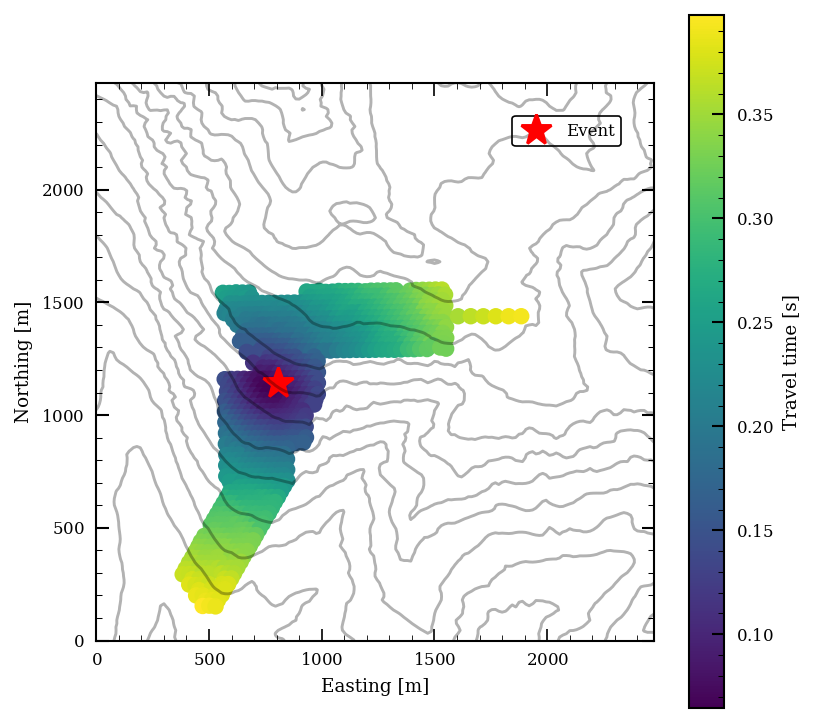

In [ ]:
# Define event index
event_idx = 100

fig, ax = plt.subplots(figsize=(6, 6))

# Get the specified event's data for all receivers
event_data = full_disp_data[event_idx]

# Create scatter plot using receiver locations from design_space_full
scatter = ax.scatter(
    design_space_full[:, 0],  # easting
    design_space_full[:, 1],  # northing
    c=event_data,       # color by travel time
    cmap='viridis',
    s=50               # marker size
)

# Plot the event location (specified event from prior_samples_full_disp)
ax.plot(
    prior_samples_full_disp[event_idx, 0],
    prior_samples_full_disp[event_idx, 1],
    'r*',
    markersize=15,
    label='Event'
)

# Add colorbar
plt.colorbar(scatter, label='Travel time [s]')

# Add contours of topography
topo_data_interp.T.plot.contour(ax=ax, levels=20, colors='k', alpha=0.3)

ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_aspect('equal')
ax.legend()

plt.show()

In [ ]:
lines_shots_path = f'{data_path}/gradient_full_shots.pt'

if os.path.exists(lines_shots_path):
    print("Loading pre-computed data...")
else:
    lines_shots_data = torch.zeros(
        len(events_full), len(design_space_full))
    
    print("Computing and saving data...")
    for i, event in tqdm(
        enumerate(events_full),
        total=len(events_full)):

        out = pyk_forward.forward(
                source_coords=event[:3].double().numpy())     
        lines_shots_data[i:, ] = torch.tensor(out.resample(
            design_space_full[..., :3].double().numpy()
            )).float()
    
    # Save computed data
    torch.save(lines_shots_data, lines_shots_path)

Loading pre-computed data...


# Shoulder only

In [ ]:
vp_model_shoulder = xr.load_dataarray(
    'data/velocity_model/3d_model_final/vp_xarray.nc',
    engine='netcdf4', format='NETCDF4')

In [ ]:
topo_spacing = 5

topo_data_interp = topo_data

topo_data_interp = topo_data.interp(
    easting=np.arange(vp_model_shoulder.easting.min(), vp_model_shoulder.easting.max(), topo_spacing),
    northing=np.arange(vp_model_shoulder.northing.min(), vp_model_shoulder.northing.max(), topo_spacing)
)

x_min, x_max, x_N = (
    topo_data_interp.easting.values.min(),
    topo_data_interp.easting.values.max(),
    topo_data_interp.easting.size)

y_min, y_max, y_N = (
    topo_data_interp.northing.values.min(),
    topo_data_interp.northing.values.max(),
    topo_data_interp.northing.size)

z_min, z_max = (
    vp_model_shoulder.elevation.min().values,
    vp_model_shoulder.elevation.max().values
)
dz = 5
z_N = int((z_max - z_min) // dz) # 2 m resolution

x = np.linspace(x_min, x_max, x_N)
y = np.linspace(y_min, y_max, y_N)
z = np.linspace(z_min, z_max, z_N)

print(f'x: {x_min} - {x_max} ({x_N})')
print(f'y: {y_min} - {y_max} ({y_N})')
print(f'z: {z_min} - {z_max} ({z_N})')

x: 511.54000899987295 - 1926.540008999873 (284)
y: 1131.6799999999348 - 1606.6799999999348 (96)
z: 1718.2709155270331 - 2414.270915527033 (139)


In [ ]:
seismic_grid = xr.DataArray(
    np.moveaxis(np.linspace(
        z_min, z_max, z_N).repeat(x_N * y_N).reshape(z_N, x_N, y_N), 0, -1),
    dims=('easting', 'northing', 'elevation'),
    coords={
        'easting': x,
        'northing': y,
        'elevation': z
    }
)

AIR_VELOCITY = 330.0
V_0 = 1000.0
V_G = 1000.0/100.0 # velocity increases by 1500 m/s per 100 m depth
V_MAX = 5500.0

elevations = (topo_data_interp.interp(
    easting=seismic_grid.easting,
    northing=seismic_grid.northing).values).repeat(z_N).reshape(x_N, y_N, z_N)

seismic_grid = elevations - seismic_grid

seismic_grid.values[ seismic_grid.values >  -topo_spacing] = \
    V_0 + V_G * seismic_grid.values[ seismic_grid.values >  -topo_spacing]
seismic_grid.values[ seismic_grid.values <= -topo_spacing] = \
    AIR_VELOCITY
seismic_grid.values[ seismic_grid.values > V_MAX] = V_MAX

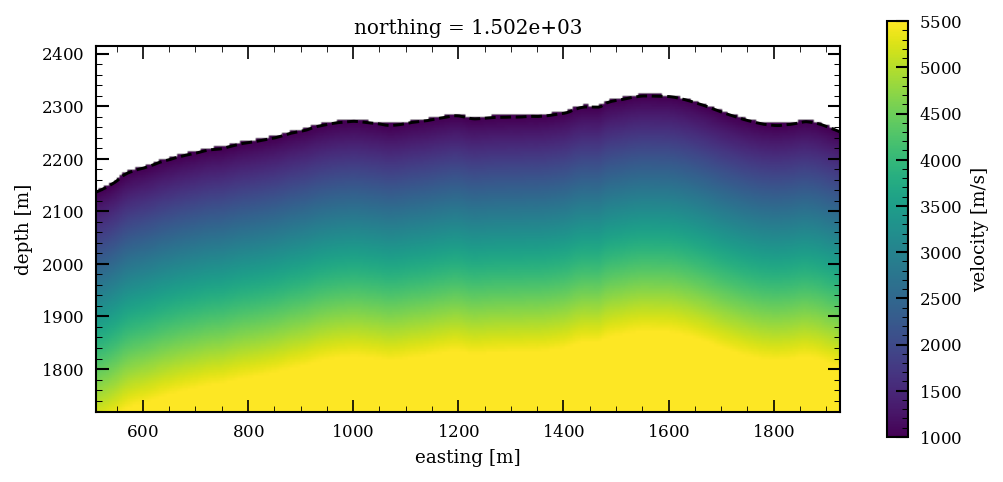

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

im_values = seismic_grid.sel(northing=1500, method='nearest').T
im_values = xr.where(im_values < 500, np.nan, im_values) 

ax.imshow(
    im_values, origin='lower',
    extent=[x_min, x_max, z_min, z_max],
    cmap='viridis', vmin=1000, vmax=5500)
ax.set_aspect('equal')

topo_data_interp.sel(
    northing=1500, method='nearest').plot(ax=ax, color='k', linestyle='--')

ax.set_xlabel('easting [m]')
ax.set_ylabel('depth [m]')

plt.colorbar(ax.images[0], ax=ax, label='velocity [m/s]', shrink=0.6)

plt.show()

In [ ]:
pyk_forward_shoulder = Pykonal_Forward(x, y, z, seismic_grid)

In [ ]:
shoulder_uniform_data_path = f'{data_path}/gradient_shoulder_uniform.pt'
shoulder_shots_data_path = f'{data_path}/gradient_shoulder_shots.pt'

# Try to load existing data
if (os.path.exists(shoulder_uniform_data_path) and \
    os.path.exists(shoulder_shots_data_path)):
    print("Loading pre-computed data...")
    shoulder_uniform_data = torch.load(shoulder_uniform_data_path)
    shoulder_shots_data = torch.load(shoulder_shots_data_path)
else:
    print("Computing and saving data...")
    shoulder_uniform_data = torch.zeros(
        len(prior_samples_shoulder_uniform), len(design_space_shoulder))
    shoulder_shots_data = torch.zeros(
        len(events_shoulder), len(design_space_shoulder))
    
    for i, receiver in tqdm(
        enumerate(design_space_shoulder),
        total=len(design_space_shoulder)):

        out = pyk_forward_shoulder.forward(
                source_coords=receiver[..., :3].double().numpy())     

        shoulder_uniform_data[:, i] = torch.tensor(out.resample(
            prior_samples_shoulder_uniform[..., :3].double().numpy()
            )).float()
        shoulder_shots_data[:, i] = torch.tensor(out.resample(
            events_shoulder[..., :3].double().numpy()
            )).float()
        
    # Save computed data
    torch.save(shoulder_uniform_data, shoulder_uniform_data_path)
    torch.save(shoulder_shots_data, shoulder_shots_data_path)

Loading pre-computed data...


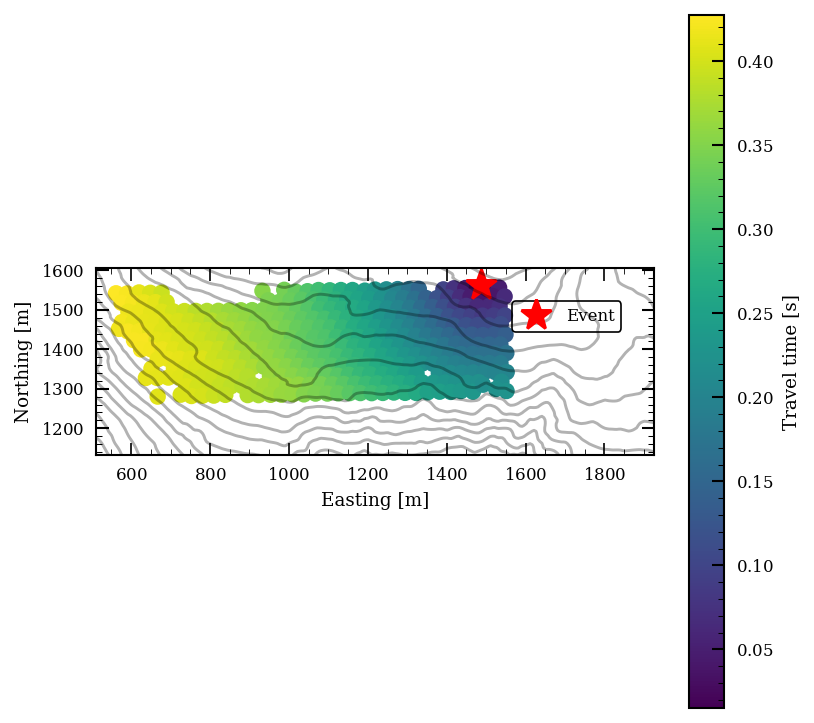

In [ ]:
# Define event index
event_idx = 1

fig, ax = plt.subplots(figsize=(6, 6))

# Get the specified event's data for all receivers
event_data = shoulder_uniform_data[event_idx]

# Create scatter plot using receiver locations from design_space_shoulder
scatter = ax.scatter(
    design_space_shoulder[:, 0],  # easting
    design_space_shoulder[:, 1],  # northing
    c=event_data,       # color by travel time
    cmap='viridis',
    s=50               # marker size
)

# Plot the event location (specified event from prior_samples_full_uniform)
ax.plot(
    prior_samples_shoulder_uniform[event_idx, 0],
    prior_samples_shoulder_uniform[event_idx, 1],
    'r*',
    markersize=15,
    label='Event'
)

# Add colorbar
plt.colorbar(scatter, label='Travel time [s]')

# Add contours of topography
topo_data_interp.T.plot.contour(ax=ax, levels=20, colors='k', alpha=0.3)

ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_aspect('equal')
ax.legend()

plt.show()